In [2]:
#import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science','notebook'])

## Principal Component Analysis 

We will do the PCA using `gromacs` tools. Tentative comparison yields quantitatively better results for `gromacs` than `MDAnalysis`.

***Notabene*** MUST USE BACKBONE AND LIGAND AS SELECTIONS, SINCE WE NEED TO LOOK AT LIGAND CONFORMATIONAL CHANGES AS WELL.


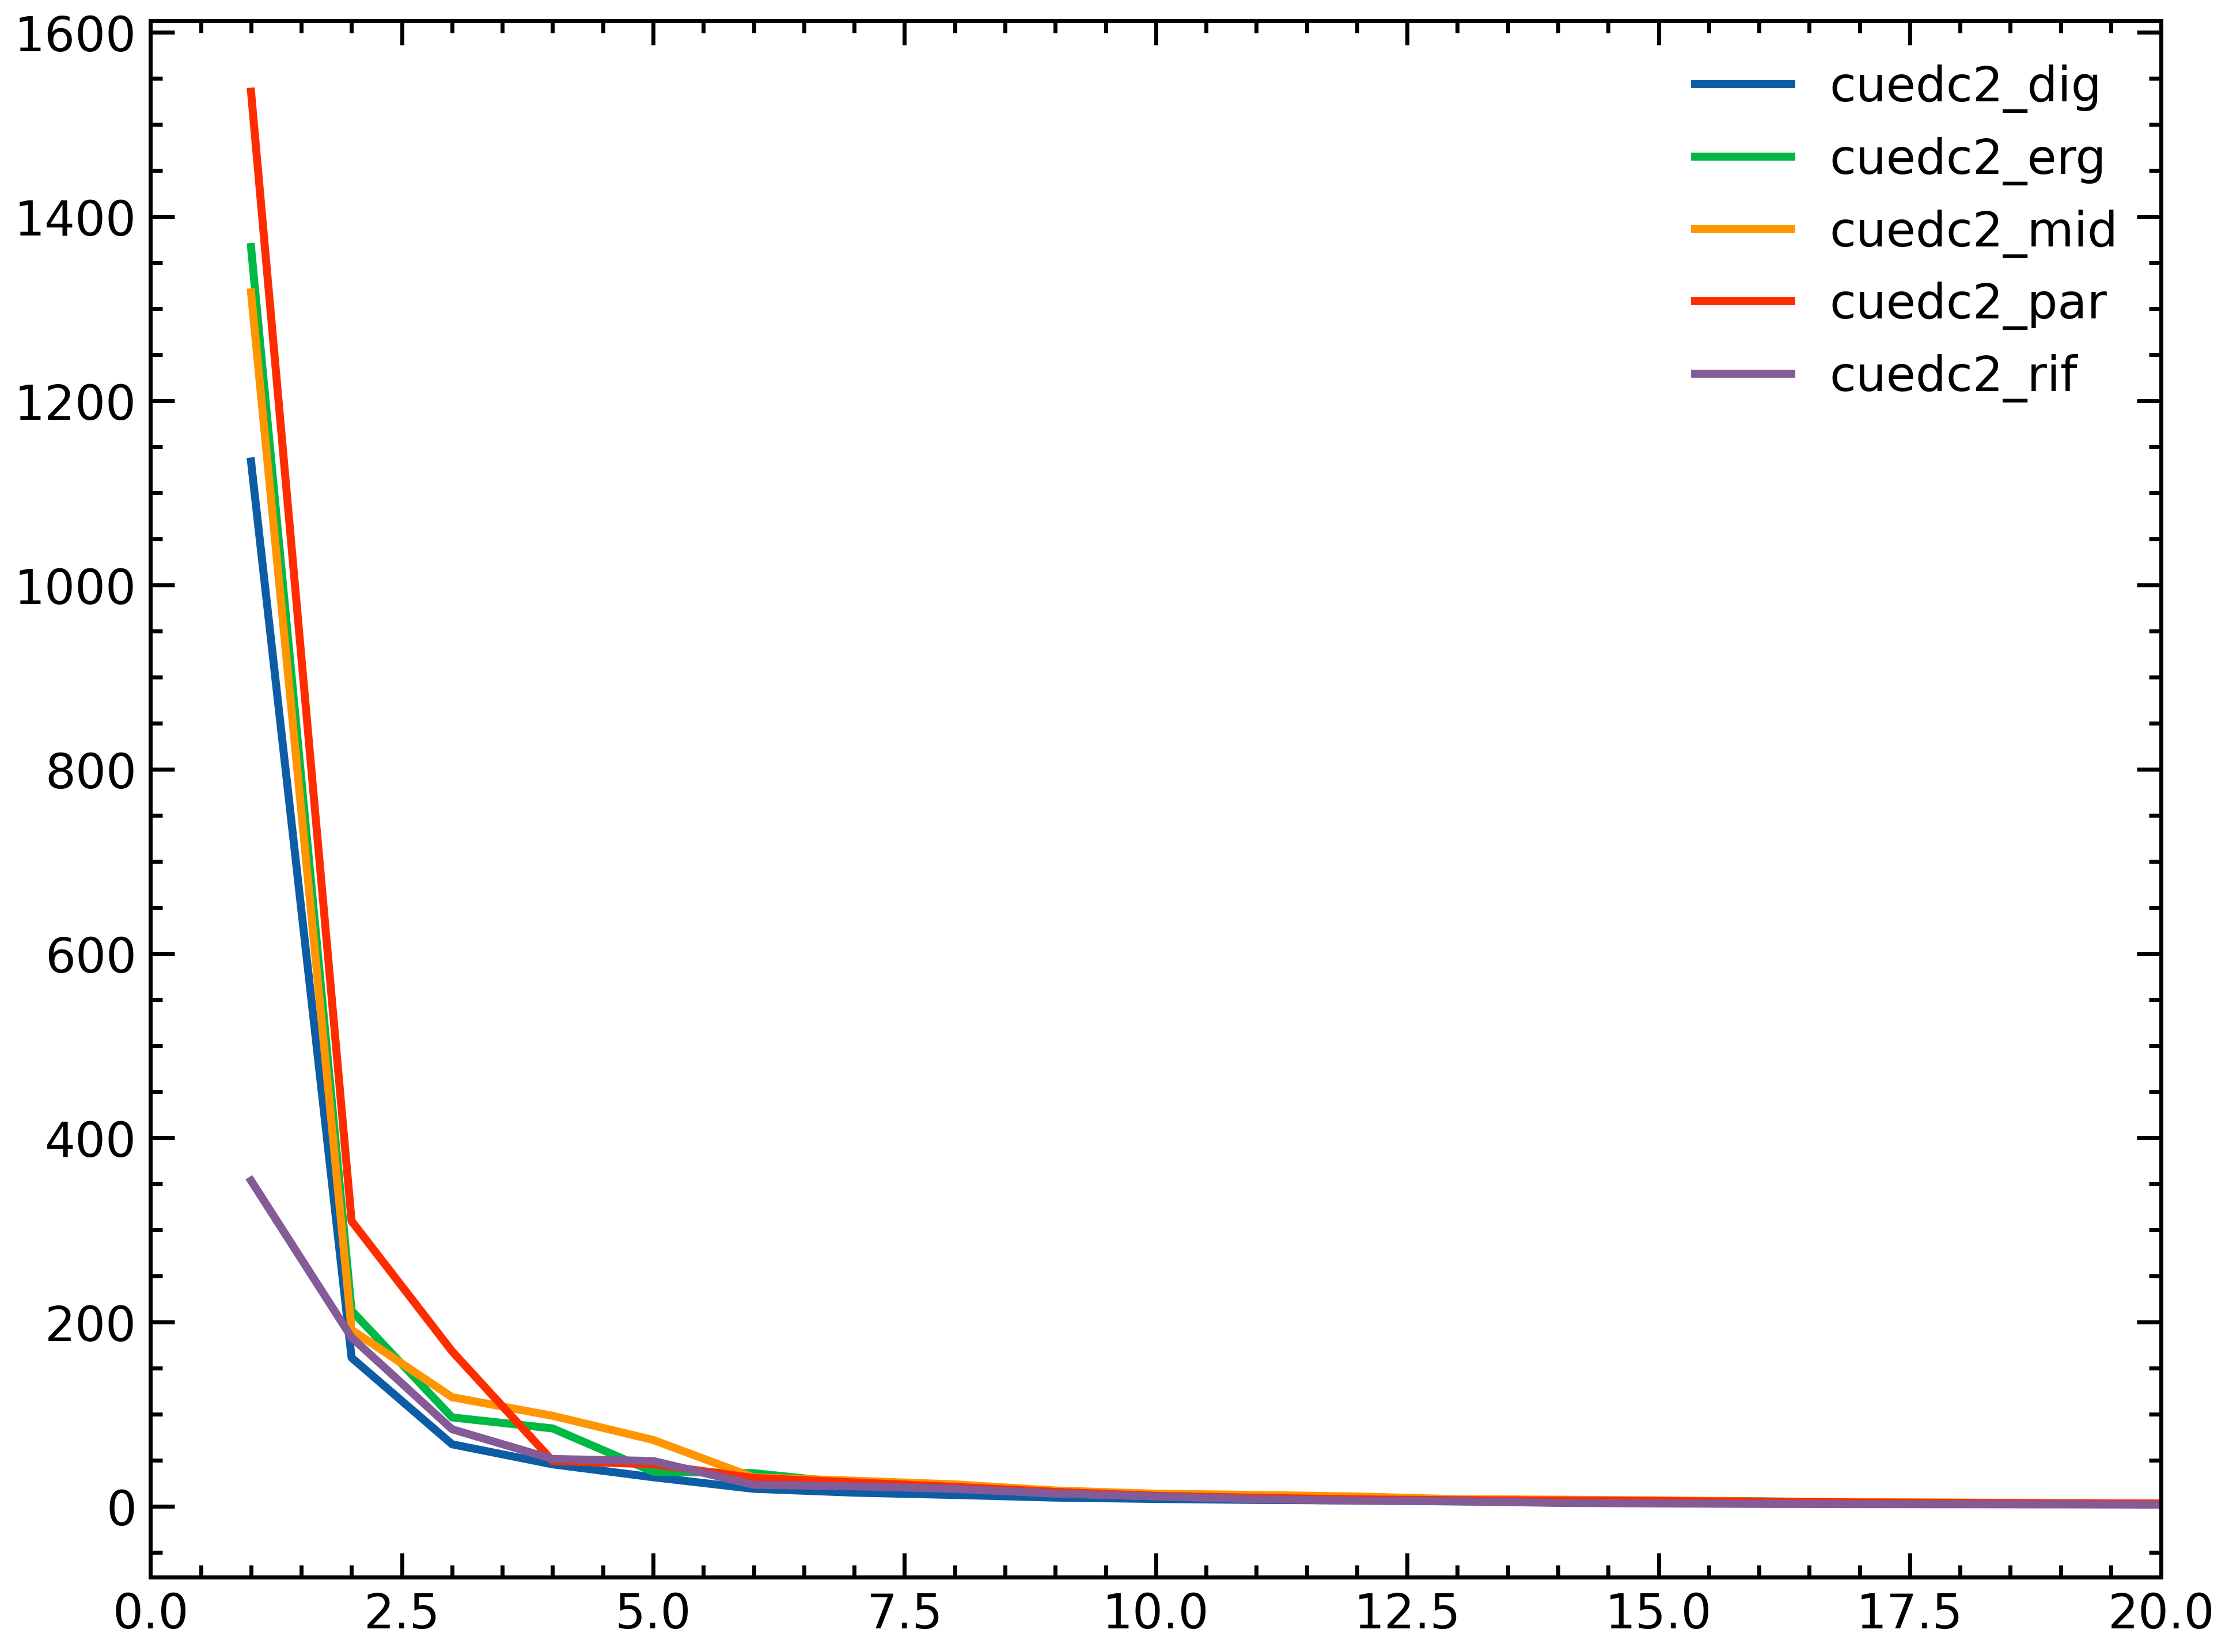

In [146]:
import numpy as np
import os
import matplotlib.pyplot as plt
complexnames = ["cuedc2_dig", "cuedc2_erg","cuedc2_mid" ,"cuedc2_par", "cuedc2_rif"]

evals_complexes = {}

for complex_name in complexnames:
    outdir = os.path.join("pca",complex_name)
    # Unpack directly into separate arrays
    eigenvector_indices, eigenvalues = np.loadtxt(
        os.path.join(outdir, f"prod_{complex_name}_eigenvalues.xvg"),
        comments=('@', '#'), 
        unpack=True
    )
    evals_complexes[complex_name] = np.vstack((eigenvector_indices, eigenvalues)).T

    plt.plot(evals_complexes[complex_name][:,0],evals_complexes[complex_name][:,1], label=complex_name )
plt.xlim(0,20)
plt.legend()


In [147]:
pcadata = {}
feldata = {}
for complex_name in complexnames:
    outdir = os.path.join("pca",complex_name)
    t, pc12_1, pc12_2 = np.loadtxt(
        os.path.join(outdir, f"prod_{complex_name}_pc1pc2.xvg"), unpack=True)
    # Unpack directly into separate arrays
    PC12_1, PC12_2, free_energy_12 = np.loadtxt(
        os.path.join(outdir, f"prod_{complex_name}_FEL12.dat"), unpack=True)
    pcadata[complex_name] = np.vstack((t, pc12_1, pc12_2)).T
    feldata[complex_name] = np.vstack((PC12_1, PC12_2, free_energy_12/4.184)).T
    


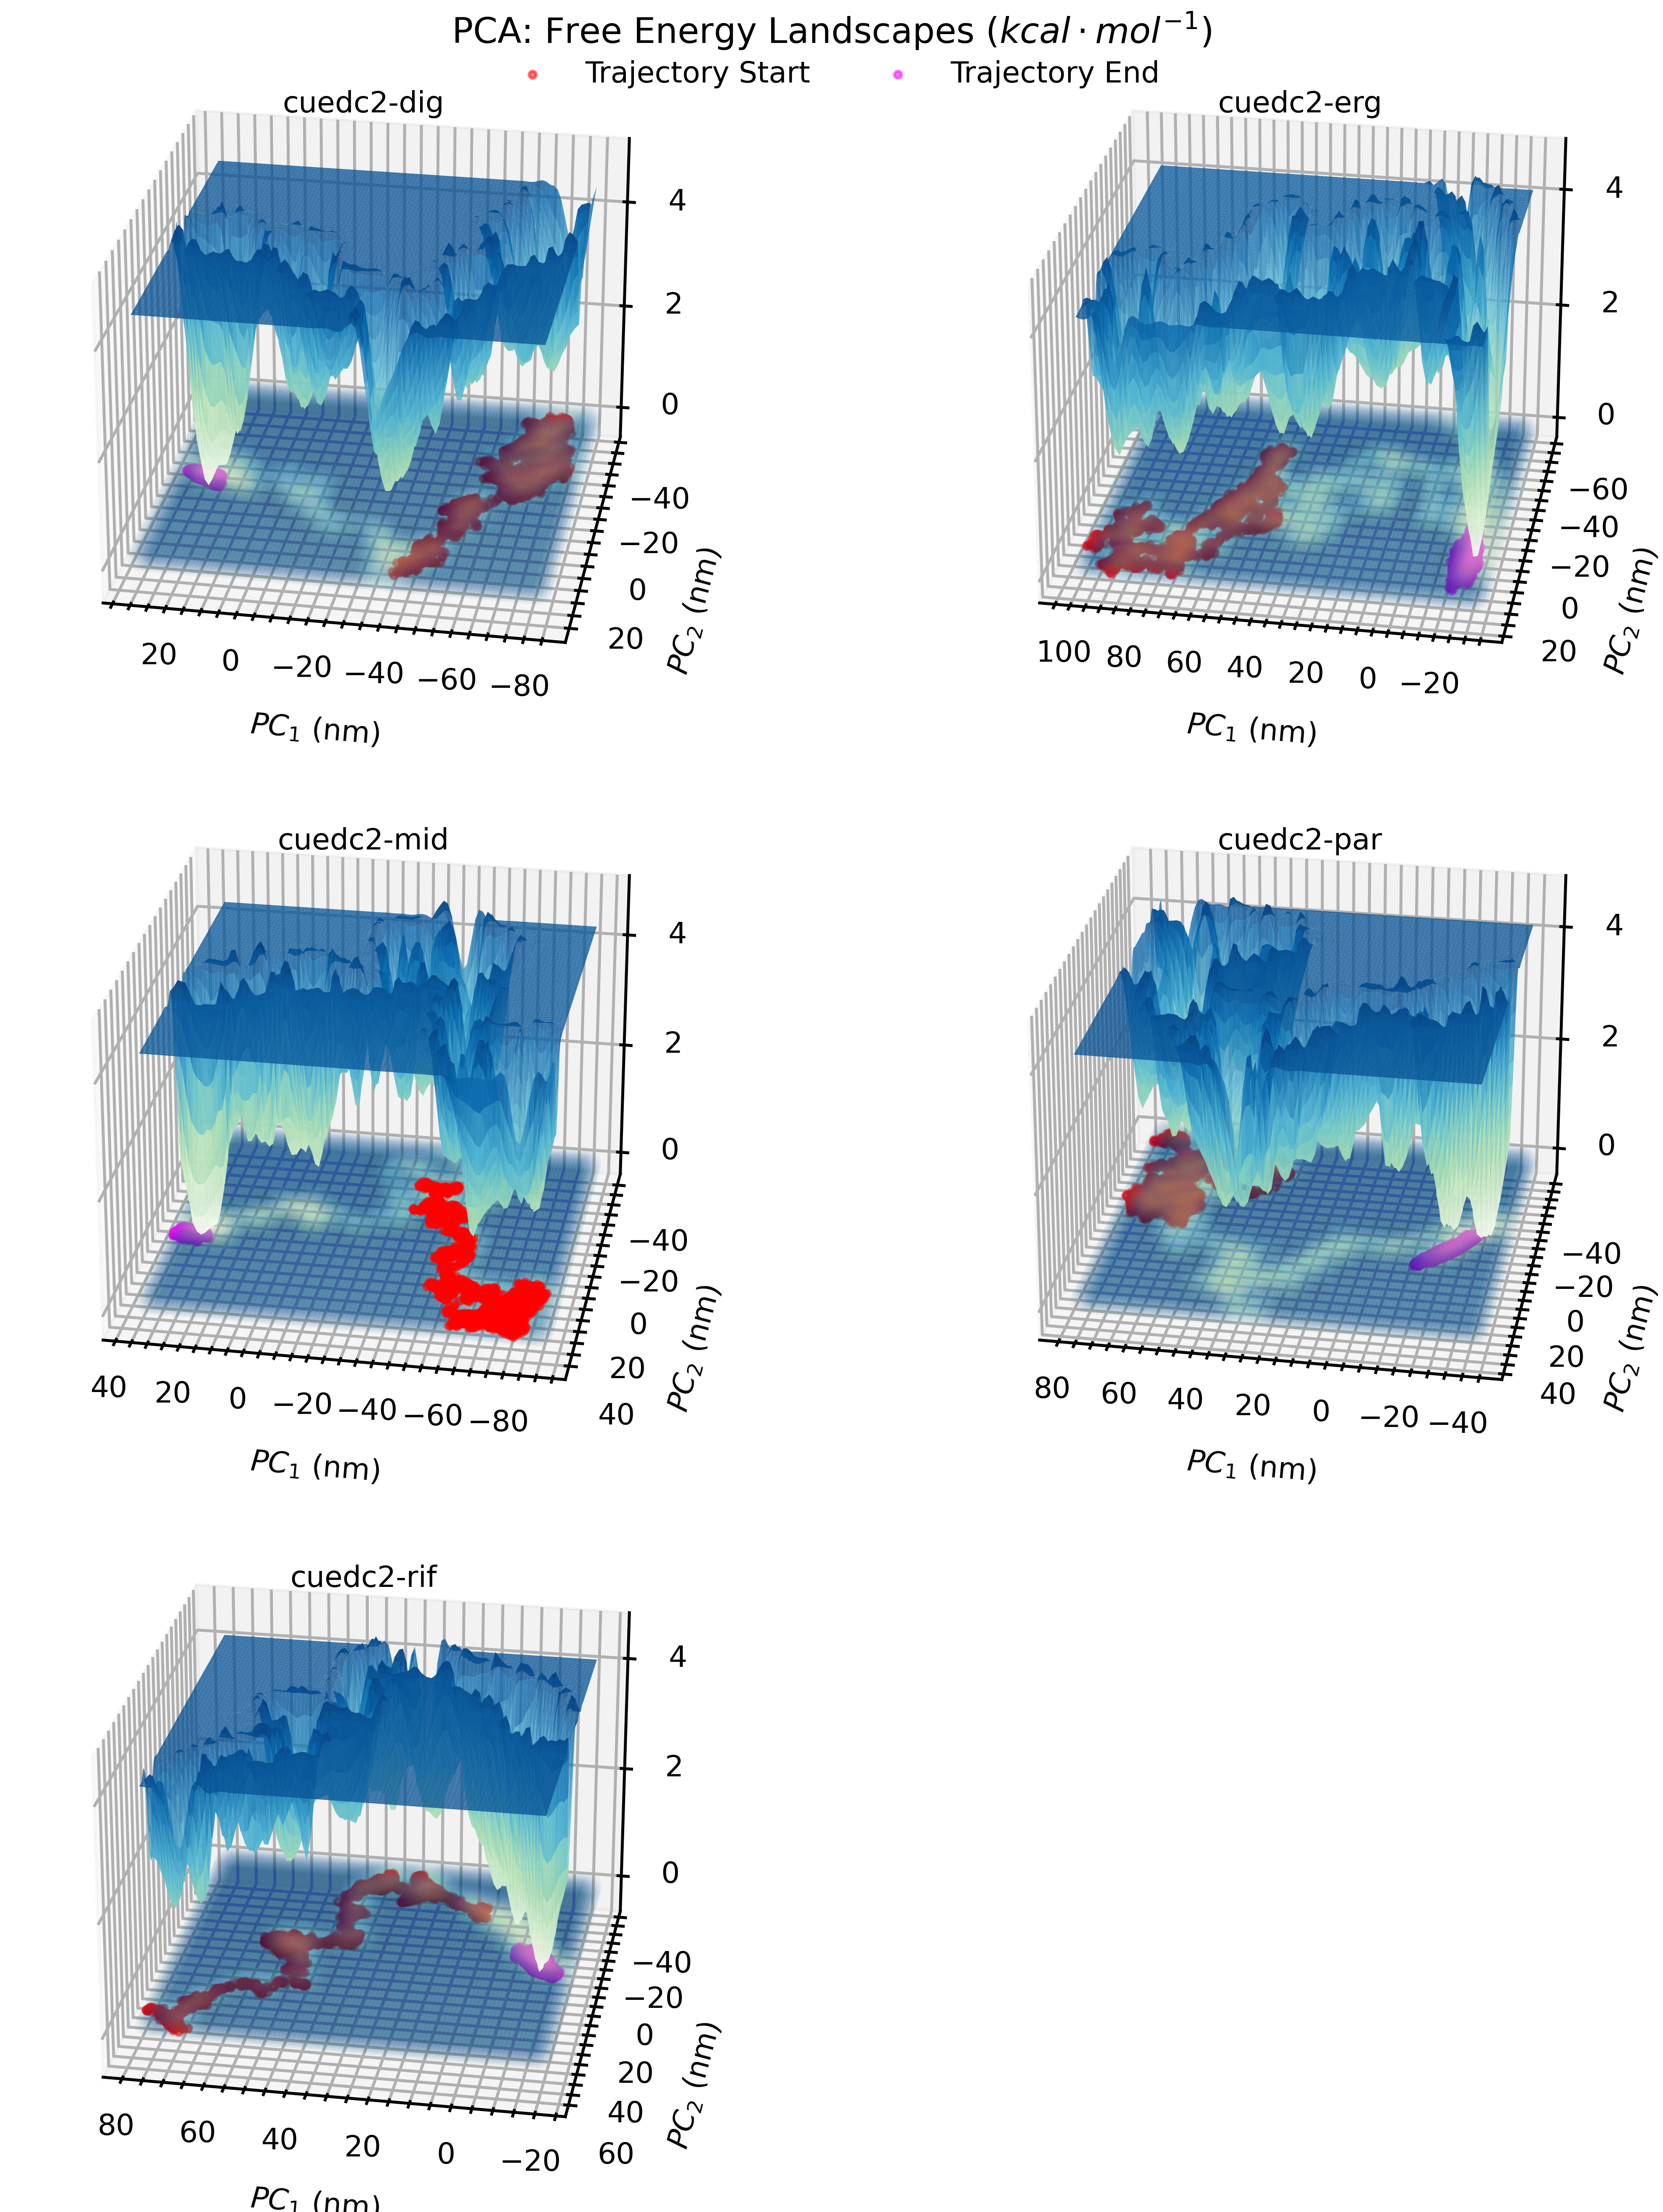

In [169]:
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata  # Changed to griddata for exact minima retention

plt.rcParams.update(
    {
        "font.size": 10,  
        "axes.labelsize": 10,  
        "xtick.labelsize": 10,  
        "ytick.labelsize": 10,  
        "legend.fontsize": 10,  
        "axes.titlesize": 10,  
    }
)

fig, axs = plt.subplots(3, 2, figsize=(10, 11), subplot_kw={'projection': '3d'})

fig.suptitle(r'PCA: Free Energy Landscapes $\left(kcal\cdot mol^{-1}\right)$', y=0.96)

for i, complex_name in enumerate(pcadata.keys()):
    ax = axs.flatten()[i]
    PC12_1 = feldata[complex_name][:,0]
    PC12_2 = feldata[complex_name][:,1]
    free_energy_kcal = feldata[complex_name][:,2]
    
    # --- CUBIC MESH INTERPOLATION ---
    # 1. Create a dense grid spanning the structural coordinates
    grid_x = np.linspace(PC12_1.min(), PC12_1.max(), 100)  # High resolution mesh
    grid_y = np.linspace(PC12_2.min(), PC12_2.max(), 100)
    X, Y = np.meshgrid(grid_x, grid_y)
    
    # 2. Map coordinates exactly onto the grid using a local cubic method
    # This prevents the wells/minima from shifting away from your trajectory points
    Z = griddata((PC12_1, PC12_2), free_energy_kcal, (X, Y), method='cubic')
    
    # 3. Plot the exact smoothed surface mesh
    ax.plot_surface(X, Y, Z, cmap='GnBu', alpha=0.8, rstride=1, cstride=1, linewidth=0, antialiased=True)
    
    # --- TRAJECTORY OVERLAYS ---
    ax.scatter(X, Y, c=Z, cmap='GnBu', s=50, alpha=0.01)
    pc1_data = pcadata[complex_name][:,1]
    pc2_data = pcadata[complex_name][:,2]

    line1 = ax.scatter(pc1_data[0:1500], pc2_data[0:1500], 0, color='red', s=6, label='Trajectory Start', alpha=0.5)
    line2 = ax.scatter(pc1_data[-1500:-1], pc2_data[-1500:-1], 0, color='magenta', s=6, label='Trajectory End', alpha=0.5)
    
    ax.set_title(complex_name.replace("_", "-"), y=0.92)
    
    ax.xaxis.set_tick_params(pad=0)
    ax.yaxis.set_tick_params(pad=5)
    ax.view_init(elev=25, azim=100)
    ax.set_zticks([0, 2, 4])
    ax.zaxis.set_tick_params(pad=5)
    ax.set_xlabel(r"$PC_1$ (nm)")
    ax.set_ylabel(r"$PC_2$ (nm)", labelpad=8)

for j in range(i + 1, len(axs.flatten())):
    axs.flatten()[j].set_visible(False)

plt.subplots_adjust(
    left=0.02, 
    right=0.98, 
    bottom=0.02, 
    top=0.88,      
    wspace=-0.05,  
    hspace=0.1     
)

fig.legend(
    handles=[line1, line2],
    loc="upper center",
    bbox_to_anchor=(0.5, 0.95),  
    ncol=2,                      
    frameon=False                
)
plt.savefig("cuedc2-antibiotics-pca12.svg", dpi=600)
plt.show()